# 05 · A Bayesian Neural Network via MCMC (NumPy)

*Companion notebook for the chapter section* **Approximations for Estimation — sampling**

Markov chain Monte Carlo (MCMC) builds a random walk through weight space whose long-run distribution is the posterior $p(\mathbf w\mid\mathcal D)$.
The collected weight vectors are **samples from the posterior**; averaging the network's predictions over them approximates the posterior predictive.

This notebook follows the spirit of Chandra & Simmons (2024), *Bayesian Neural Networks via MCMC: A Python-Based Tutorial*, and implements two samplers from scratch:

1. **Random-walk Metropolis–Hastings** — simple, but slow in high dimensions.
2. **Langevin (MALA)** — uses the gradient to propose better moves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. Data and network
A one-hidden-layer tanh network, $f_{\mathbf w}(x)=W_2^\top\tanh(W_1x+\mathbf b_1)+b_2$, with $H=10$ hidden units — **31 weights** in total, packed into one vector $\mathbf w$.

In [2]:
x = np.concatenate([rng.uniform(-3, -0.8, 20), rng.uniform(0.8, 3, 20)])
y = np.sin(1.5 * x) + 0.1 * rng.standard_normal(len(x))
xg = np.linspace(-5, 5, 300)

H = 10
D = 3 * H + 1                                     # W1 (H), b1 (H), W2 (H), b2 (1)

def unpack(w):
    return w[:H], w[H:2*H], w[2*H:3*H], w[3*H]

def forward(w, x):
    W1, b1, W2, b2 = unpack(w)
    return np.tanh(np.outer(x, W1) + b1) @ W2 + b2
print("number of weights:", D)

number of weights: 31


## 2. The log-posterior and its gradient

* Likelihood: $y_i\sim\mathcal N(f_{\mathbf w}(x_i),\sigma^2)$ with $\sigma=0.1$ assumed known.
* Prior: $\mathbf w\sim\mathcal N(\mathbf 0,s^2I)$ with $s=1$.

$$\log p(\mathbf w\mid\mathcal D)=-\frac1{2\sigma^2}\sum_i\big(y_i-f_{\mathbf w}(x_i)\big)^2-\frac1{2s^2}\lVert\mathbf w\rVert^2+\text{const}$$

MCMC only needs the posterior **up to a constant** — which is why it works even though $p(\mathcal D)$ is intractable.

In [3]:
sigma, s_prior = 0.1, 1.0

def log_post(w):
    r = y - forward(w, x)
    return -0.5 * np.sum(r**2) / sigma**2 - 0.5 * np.sum(w**2) / s_prior**2

def grad_log_post(w):
    W1, b1, W2, b2 = unpack(w)
    Hid = np.tanh(np.outer(x, W1) + b1)                # (n, H)
    r = y - (Hid @ W2 + b2)                            # residuals
    g_out = r / sigma**2                               # d loglik / d f
    gW2 = Hid.T @ g_out; gb2 = g_out.sum()
    g_hid = np.outer(g_out, W2) * (1 - Hid**2)         # back through tanh
    gW1 = (g_hid * x[:, None]).sum(0); gb1 = g_hid.sum(0)
    return np.concatenate([gW1, gb1, gW2, [gb2]]) - w / s_prior**2

# gradient check
w0 = rng.standard_normal(D); e = np.zeros(D); e[4] = 1e-6
print("analytic:", grad_log_post(w0)[4], " numeric:", (log_post(w0 + e) - log_post(w0 - e)) / 2e-6)

analytic: -877.588613288437  numeric: -877.5886135481414


## 3. Random-walk Metropolis–Hastings

Propose $\mathbf w'=\mathbf w+\epsilon\,\mathbf z$ with $\mathbf z\sim\mathcal N(0,I)$ and accept with probability

$$\min\Big(1,\;\frac{p(\mathbf w'\mid\mathcal D)}{p(\mathbf w\mid\mathcal D)}\Big).$$

In [4]:
def random_walk_mh(n_iter, step, w_init):
    w, lp = w_init.copy(), log_post(w_init)
    chain, accepted = np.empty((n_iter, D)), 0
    for t in range(n_iter):
        w_new = w + step * rng.standard_normal(D)
        lp_new = log_post(w_new)
        if np.log(rng.random()) < lp_new - lp:
            w, lp = w_new, lp_new; accepted += 1
        chain[t] = w
    return chain, accepted / n_iter

w_init = rng.normal(0, 0.5, D)
chain_rw, acc_rw = random_walk_mh(60_000, step=0.01, w_init=w_init)
print(f"random walk acceptance rate: {acc_rw:.2f}")

random walk acceptance rate: 0.26


## 4. Langevin proposals (MALA)

Move **uphill** along the gradient, then add noise:

$$\mathbf w'=\mathbf w+\tfrac{\epsilon^2}{2}\nabla\log p(\mathbf w\mid\mathcal D)+\epsilon\,\mathbf z .$$

Because this proposal is not symmetric, the acceptance ratio includes the proposal densities $q$:

$$\alpha=\min\Big(1,\frac{p(\mathbf w')\,q(\mathbf w\mid\mathbf w')}{p(\mathbf w)\,q(\mathbf w'\mid\mathbf w)}\Big),\qquad
q(\mathbf a\mid\mathbf b)=\mathcal N\big(\mathbf a;\,\mathbf b+\tfrac{\epsilon^2}{2}\nabla\log p(\mathbf b),\,\epsilon^2I\big).$$

In [5]:
def mala(n_iter, step, w_init):
    def log_q(a, b, gb):                               # log q(a | b), up to a constant
        return -np.sum((a - b - 0.5 * step**2 * gb) ** 2) / (2 * step**2)
    w = w_init.copy(); lp = log_post(w); g = grad_log_post(w)
    chain, accepted = np.empty((n_iter, D)), 0
    for t in range(n_iter):
        w_new = w + 0.5 * step**2 * g + step * rng.standard_normal(D)
        lp_new, g_new = log_post(w_new), grad_log_post(w_new)
        log_alpha = lp_new - lp + log_q(w, w_new, g_new) - log_q(w_new, w, g)
        if np.log(rng.random()) < log_alpha:
            w, lp, g = w_new, lp_new, g_new; accepted += 1
        chain[t] = w
    return chain, accepted / n_iter

chain_mala, acc_mala = mala(60_000, step=0.008, w_init=w_init)
print(f"MALA acceptance rate: {acc_mala:.2f}")

MALA acceptance rate: 0.62


## 5. Diagnostics: traces and the log-posterior

Discard the first part of the chain (**burn-in**), while it is still travelling from the random start to the high-probability region.

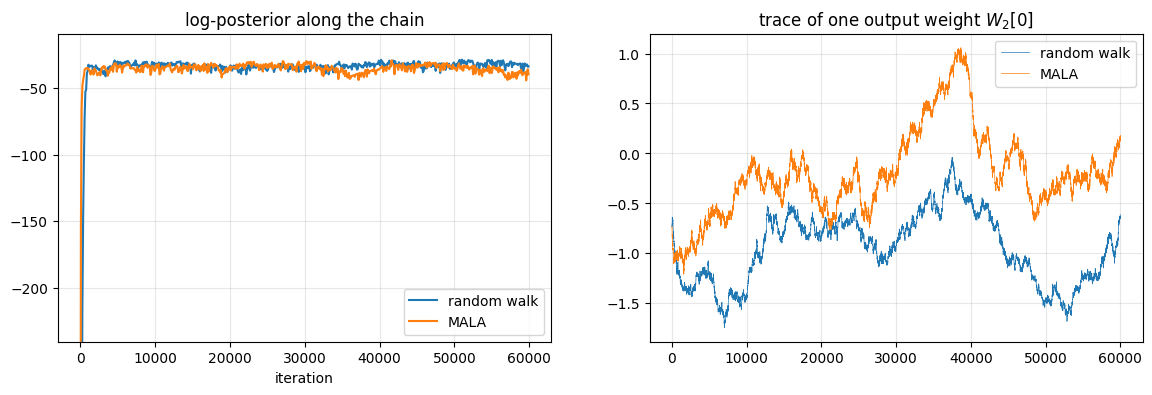

In [6]:
lp_rw = [log_post(w) for w in chain_rw[::100]]
lp_ml = [log_post(w) for w in chain_mala[::100]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(np.arange(0, 60_000, 100), lp_rw, label="random walk"); ax[0].plot(np.arange(0, 60_000, 100), lp_ml, label="MALA")
ax[0].set_ylim(np.percentile(lp_ml, 5) - 200, max(lp_ml) + 20)
ax[0].set_title("log-posterior along the chain"); ax[0].set_xlabel("iteration"); ax[0].legend()
ax[1].plot(chain_rw[:, 2 * H], lw=0.5, label="random walk"); ax[1].plot(chain_mala[:, 2 * H], lw=0.5, label="MALA")
ax[1].set_title("trace of one output weight $W_2[0]$"); ax[1].legend()
plt.show()

## 6. The posterior predictive

Keep every 40th sample after burn-in (**thinning**), push $x$ through each sampled network, and summarise. Adding the noise $\sigma$ back gives the full predictive band.

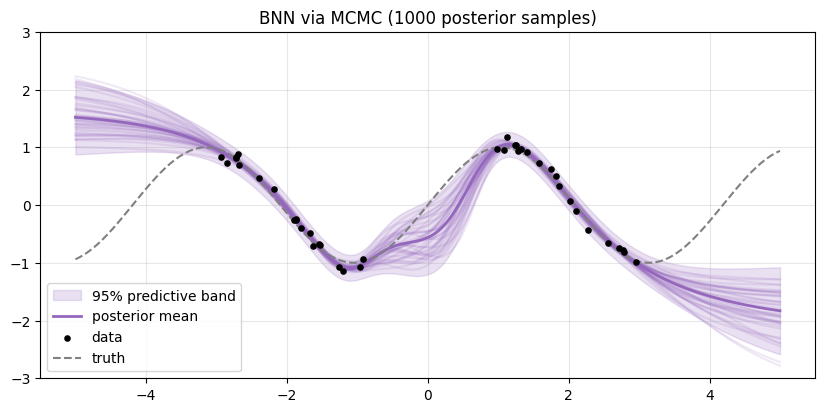

In [7]:
burn = 20_000
samples = chain_mala[burn::40]
F = np.array([forward(w, xg) for w in samples])       # (n_samples, len(xg))
mu, sd_epi = F.mean(0), F.std(0)
sd_tot = np.sqrt(sd_epi**2 + sigma**2)

fig, ax = plt.subplots(figsize=(10, 4.5))
for f_ in F[::25]:
    ax.plot(xg, f_, c="C4", alpha=0.15)
ax.fill_between(xg, mu - 2 * sd_tot, mu + 2 * sd_tot, color="C4", alpha=0.2, label="95% predictive band")
ax.plot(xg, mu, c="C4", lw=2, label="posterior mean")
ax.scatter(x, y, c="k", s=14, zorder=3, label="data")
ax.plot(xg, np.sin(1.5 * xg), "--", c="gray", label="truth")
ax.set_ylim(-3, 3); ax.legend(loc="lower left"); ax.set_title(f"BNN via MCMC ({len(samples)} posterior samples)")
plt.show()

### Posterior of a single weight
Individual weights are usually poorly identified: many weight combinations produce almost the same function, so the marginal posteriors are wide, skewed or lumpy — very different from the Gaussian of notebook 04. Swapping two hidden units gives an identical network, so the true posterior also has many symmetric copies of every mode; a single chain explores only one. Lumpy histograms are also a warning that the chain has not mixed fully — the traces above show strong autocorrelation, so a longer run (or HMC) would give smoother marginals. Fortunately, the **predictions** (the quantity we care about) are far more stable than individual weights.

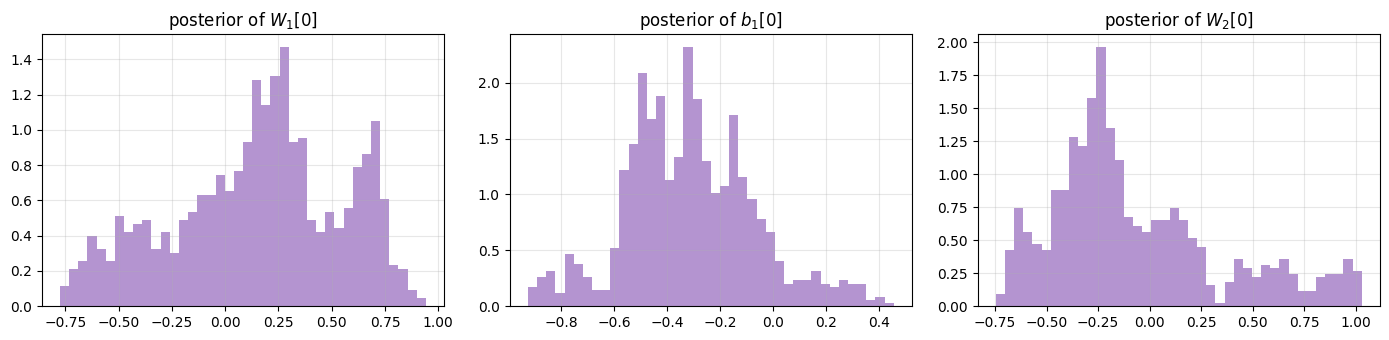

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, j, name in zip(axes, [0, H, 2 * H], ["$W_1[0]$", "$b_1[0]$", "$W_2[0]$"]):
    ax.hist(samples[:, j], bins=40, color="C4", alpha=0.7, density=True); ax.set_title(f"posterior of {name}")
plt.tight_layout(); plt.show()

## Why not always use MCMC?

* **Pros**: asymptotically exact; no assumption about the shape of the posterior.
* **Cons**: each step needs the *full* data set; mixing is slow in millions of dimensions; convergence is hard to diagnose.

This is why large BNNs usually rely on **variational inference** (next notebook). For stochastic-gradient variants (SGLD, SG-HMC) and parallel tempering, see Chandra & Simmons (2024).

## Exercises
1. Run two chains from different starts and compare their predictive means. Do they agree? (Compute the Gelman–Rubin $\hat R$ for a few weights.)
2. Treat the noise as unknown: sample $\log\sigma$ as an extra parameter with its own prior.
3. Implement **Hamiltonian Monte Carlo** using `grad_log_post` (leapfrog steps). Compare acceptance and trace plots with MALA.
4. Change `step` for both samplers. What acceptance rates give the best-looking traces? (Theory suggests ≈0.23 for random walk and ≈0.57 for MALA.)